In [1]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("HF_TOKEN")

In [2]:
!pip install transformers datasets soundfile librosa optuna evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.2 MB/s eta 0:00:00


In [3]:
import os
import librosa
from transformers import Wav2Vec2FeatureExtractor, Wav2Vec2Processor, Wav2Vec2Model, TrainingArguments, Trainer
import torch
from tqdm.auto import tqdm
import pandas as pd
import json
import re
import torch.nn as nn
import optuna
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import evaluate
import random
from optuna.visualization import plot_terminator_improvement, plot_param_importances
from datasets import Dataset, load_dataset
import torchaudio
from pydub import AudioSegment
import io
import shutil
import glob
import librosa.display
from transformers.modeling_outputs import SequenceClassifierOutput
import soundfile as sf

/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


In [4]:
model_checkpoint = "facebook/wav2vec2-xls-r-300m"

feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(
    model_checkpoint,
    do_normalize=True,
    return_attention_mask=True
)

print(f"Feature Extractor initialized for Dialect Detection from: {model_checkpoint}")
print(f"Sampling Rate: {feature_extractor.sampling_rate} Hz")
print(f"Normalization: {feature_extractor.do_normalize}")
print(f"Attention Mask: {feature_extractor.return_attention_mask}")

preprocessor_config.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

Feature Extractor initialized for Dialect Detection from: facebook/wav2vec2-xls-r-300m
Sampling Rate: 16000 Hz
Normalization: True
Attention Mask: True


In [6]:
import os
import librosa
import torch

base_train_dir = '/kaggle/input/dialectal-datasets/Train_Data_Fixed/Train'
audio_dir_bd = os.path.join(base_train_dir, 'bn_bd')
audio_dir_in = os.path.join(base_train_dir, 'bn_in')

def extract_features(audio_path):
    """
    Loads audio and converts to model-ready features.
    """
    # Load audio at model's required sampling rate
    audio_input, _ = librosa.load(audio_path, sr=feature_extractor.sampling_rate)
    
    # Extract features
    features = feature_extractor(
        audio_input, 
        sampling_rate=feature_extractor.sampling_rate, 
        return_tensors="pt"
    )
    
    # Label 0 for bn_bd, Label 1 for bn_in
    label = 0 if 'bn_bd' in audio_path else 1
    
    return features['input_values'], label

# --- Application to your existing train_audio_paths ---
# This processes the first sample from your previously split list
train_audio_paths= ["/kaggle/input/datasets/pradiphazra2/dialectal-datasets/Train_Data_Fixed/Train/bn_in/AddBackgroundNoise_WestBengal_Darjeeling_0_addbackgroundnoise.wav"]
if train_audio_paths:
    sample_path = train_audio_paths[0]
    input_values, label = extract_features(sample_path)
    
    print(f"Processed: {os.path.basename(sample_path)}")
    print(f"Feature Shape: {input_values.shape}")
    print(f"Label: {label} ({'bn_bd' if label == 0 else 'bn_in'})")


Processed: AddBackgroundNoise_WestBengal_Darjeeling_0_addbackgroundnoise.wav
Feature Shape: torch.Size([1, 80000])
Label: 1 (bn_in)


In [7]:
id2label = {0: "bn_bd", 1: "bn_in"}
label2id = {"bn_bd": 0, "bn_in": 1}

# Load the model for Sequence Classification
base_model = Wav2Vec2Model.from_pretrained(model_checkpoint)
base_model.freeze_feature_encoder()

for param in base_model.parameters():
    param.requires_grad = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_model.to(device)
print(f"XLS-R 300M Classification model loaded onto: {device}")
print(f"Labels configured: {base_model.config.id2label}")
print("Base layers frozen. Only the classification head is trainable.")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-xls-r-300m
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


XLS-R 300M Classification model loaded onto: cuda
Labels configured: {0: 'LABEL_0', 1: 'LABEL_1'}
Base layers frozen. Only the classification head is trainable.


In [9]:
base_model.eval()
base_model.to(device)

# 2. Get the processed features from your previous step
inputs = features['input_values'].to(device)

# 3. Pass through the base model (without calculating gradients)
with torch.no_grad():
    outputs = base_model(inputs)
    last_hidden_state = outputs.last_hidden_state

# 4. Print the results
print(f"\n--- Base Model Output Verification ---")
print(f"Output Tensor Shape: {last_hidden_state.shape}") 
# Expected: [1, Time_Steps, 1024]

print(f"Batch size: {last_hidden_state.shape[0]}")
print(f"Sequence length (Time steps): {last_hidden_state.shape[1]}")
print(f"Hidden Dimension (The number you need for nn.Linear): {last_hidden_state.shape[2]}")

NameError: name 'model' is not defined

In [10]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [16]:
import os
import random
import torch
import librosa
from sklearn.model_selection import train_test_split
from transformers import Wav2Vec2FeatureExtractor, Wav2Vec2ForSequenceClassification, TrainingArguments, Trainer

# 1. Exact Kaggle Paths
base_path = '/kaggle/input/datasets/pradiphazra2/dialectal-datasets/Train_Data_Fixed/Train'
dir_bd = os.path.join(base_path, 'bn_bd')
dir_in = os.path.join(base_path, 'bn_in')

# 2. Collect Files
all_data = []
for directory, label in [(dir_bd, 0), (dir_in, 1)]:
    if os.path.exists(directory):
        for root, _, files in os.walk(directory):
            for file in files:
                if file.lower().endswith('.wav'):
                    all_data.append((os.path.join(root, file), label))

# 3. Split Data (80% Train, 20% Val)
train_data, val_data = train_test_split(all_data, test_size=0.20, random_state=42, shuffle=True)

# 4. Initialize Model and Feature Extractor
model_name = "facebook/wav2vec2-base-960h" # Or your specific checkpoint
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(model_name)
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    model_name, 
    num_labels=2,
    label2id={"bn_bd": 0, "bn_in": 1},
    id2label={0: "bn_bd", 1: "bn_in"}
)

print(f"Setup Complete. Training samples: {len(train_data)}, Validation samples: {len(val_data)}")


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status     | 
---------------------------+------------+-
lm_head.weight             | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
projector.bias             | MISSING    | 
projector.weight           | MISSING    | 
wav2vec2.masked_spec_embed | MISSING    | 
classifier.bias            | MISSING    | 
classifier.weight          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Setup Complete. Training samples: 2750, Validation samples: 688


In [ ]:
import torch
import torch.nn as nn
from transformers.modeling_outputs import SequenceClassifierOutput

class DialectClassifier(nn.Module):
    def __init__(self, base_model, n_layers, hidden_dim, act_fn, dropout_p, num_labels=2):
        super(DialectClassifier, self).__init__()
        self.base_model = base_model
        
        layers = []
        current_dim = 1024 
        for i in range(n_layers):
            layers.append(nn.Linear(current_dim, hidden_dim))
            layers.append(act_fn())
            if dropout_p > 0:
                layers.append(nn.Dropout(dropout_p))
            current_dim = hidden_dim
            
        layers.append(nn.Linear(current_dim, num_labels))
        self.classifier_head = nn.Sequential(*layers)

    def forward(self, input_values, labels=None, output_attentions=False, **kwargs):
        if input_values.ndim == 3:
            input_values = input_values.squeeze(1)
            
        outputs = self.base_model(input_values, output_attentions=output_attentions)
        pooled_output = torch.mean(outputs.last_hidden_state, dim=1)
        logits = self.classifier_head(pooled_output)
        
        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits, labels)

        return SequenceClassifierOutput(
            loss=loss,
            logits=logits,
            hidden_states=outputs.hidden_states,
            attentions=outputs.attentions 
        )


In [18]:
import numpy as np
import evaluate
import librosa
from torch.utils.data import Dataset as TorchDataset
from transformers import Trainer, TrainingArguments

# 1. Custom Dataset to load audio from your train_data/val_data paths
class AudioDataset(TorchDataset):
    def __init__(self, data_list, feature_extractor):
        self.data_list = data_list # List of (path, label)
        self.feature_extractor = feature_extractor

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        path, label = self.data_list[idx]
        audio, _ = librosa.load(path, sr=self.feature_extractor.sampling_rate)
        features = self.feature_extractor(audio, sampling_rate=self.feature_extractor.sampling_rate, return_tensors="pt")
        return {
            "input_values": features.input_values, # Model's forward handles the squeeze
            "labels": torch.tensor(label, dtype=torch.long)
        }

# 2. Metrics & Fixed Collator
metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

def data_collator(features):
    # Ensure input_values are lists of arrays for the feature_extractor's pad method
    input_features = [{"input_values": f["input_values"].squeeze().numpy()} for f in features]
    label_features = [f["labels"] for f in features]
    
    batch = feature_extractor.pad(input_features, padding=True, return_tensors="pt")
    batch["labels"] = torch.stack(label_features)
    return batch

# 3. Model Initialization with your best_params
best_params = {
    "learning_rate": 4.253162363790868e-05,
    "weight_decay": 0.00010821382910613992,
    "hidden_dim": 1024,
    "n_linear": 2,
    "activation": "LeakyReLU",
    "num_epochs": 45
}

activation_map = {"ReLU": nn.ReLU, "LeakyReLU": nn.LeakyReLU, "GELU": nn.GELU, "SiLU": nn.SiLU}
best_act_fn = activation_map[best_params["activation"]]

# Initialize your specific architecture
model = DialectClassifier(
    base_model=base_model,
    n_layers=best_params["n_linear"],        
    hidden_dim=best_params["hidden_dim"],    
    act_fn=best_act_fn,                      
    dropout_p=0.0, # As per best_params["use_dropout"] = False
    num_labels=2
).to(device)

# 4. Define Training Arguments
training_args = TrainingArguments(
    output_dir="./dialect_detection_final",
    per_device_train_batch_size=8, 
    gradient_accumulation_steps=2,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    learning_rate=best_params["learning_rate"], 
    weight_decay=best_params["weight_decay"], 
    num_train_epochs=best_params["num_epochs"],
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=True if torch.cuda.is_available() else False,
    optim="adamw_torch",
    remove_unused_columns=False # Critical for custom nn.Modules
)

# 5. Initialize and Run Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=AudioDataset(train_data, feature_extractor),
    eval_dataset=AudioDataset(val_data, feature_extractor),
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print(f"Starting training for {best_params['num_epochs']} epochs...")
trainer.train()


Starting training for 45 epochs...


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy
1,2.772883,1.378722,0.524709
2,2.710584,1.361471,0.533430
3,2.618099,1.329599,0.623547
4,2.424757,1.289914,0.693314
5,2.229163,1.265154,0.616279
6,2.312262,1.319664,0.527616
7,2.043986,1.194787,0.651163
8,2.077259,1.135132,0.738372
9,2.085049,1.653860,0.524709
10,1.973898,1.217040,0.609012


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector

TrainOutput(global_step=3870, training_loss=1.7188434310045662, metrics={'train_runtime': 8070.806, 'train_samples_per_second': 15.333, 'train_steps_per_second': 0.48, 'total_flos': 0.0, 'train_loss': 1.7188434310045662, 'epoch': 45.0})

In [19]:
import os
save_directory = "/kaggle/working/dialect_classifier_final"
os.makedirs(save_directory, exist_ok=True)
trainer.save_model(save_directory)
feature_extractor.save_pretrained(save_directory)
torch.save(model.state_dict(), os.path.join(save_directory, "custom_model_weights.pt"))
print(f"✅ Model successfully saved to: {save_directory}")
print("Download this folder or use it as an 'Input' in your next Kaggle notebook.")


✅ Model successfully saved to: /kaggle/working/dialect_classifier_final
Download this folder or use it as an 'Input' in your next Kaggle notebook.


In [20]:
!zip -r augmented_base_model.zip /kaggle/working/dialect_classifier_final

  adding: kaggle/working/dialect_classifier_final/ (stored 0%)
  adding: kaggle/working/dialect_classifier_final/preprocessor_config.json (deflated 33%)
  adding: kaggle/working/dialect_classifier_final/model.safetensors (deflated 41%)
  adding: kaggle/working/dialect_classifier_final/custom_model_weights.pt (deflated 41%)
  adding: kaggle/working/dialect_classifier_final/training_args.bin (deflated 53%)


In [23]:
import os
import shutil
from tqdm import tqdm

# 1. Define Source (Kaggle Input) and Destination (Kaggle Working)
# Using the exact path discovered in your previous steps
test_source_base = '/kaggle/input/datasets/pradiphazra2/dialectal-datasets/Test_Data_Fixed/Test'
output_base = '/kaggle/working/flattened_test_data'

# 2. Create the two target directories
dialects = ['bn_bd', 'bn_in']
for d in dialects:
    os.makedirs(os.path.join(output_base, d), exist_ok=True)

# 3. Walk through all subfolders and copy files
print("Flattening test data into primary dialect folders...")
for dialect in dialects:
    source_dialect_path = os.path.join(test_source_base, dialect)
    target_dialect_folder = os.path.join(output_base, dialect)
    
    # os.walk automatically enters AddBackgroundNoise, Pitchup, etc.
    for root, _, files in os.walk(source_dialect_path):
        for file in files:
            if file.lower().endswith('.wav'):
                src_file_path = os.path.join(root, file)
                # Save to the flat folder (bn_bd or bn_in)
                dest_file_path = os.path.join(target_dialect_folder, file)
                
                # Use copy2 to preserve metadata
                shutil.copy2(src_file_path, dest_file_path)

print(f"✅ Success! Flattened test data is ready at: {output_base}")

Flattening test data into primary dialect folders...
✅ Success! Flattened test data is ready at: /kaggle/working/flattened_test_data


In [24]:
test_data_ready = []

for label, dialect in enumerate(['bn_bd', 'bn_in']):
    folder = os.path.join(output_base, dialect)
    for file in os.listdir(folder):
        if file.endswith('.wav'):
            test_data_ready.append((os.path.join(folder, file), label))

print(f"Total Test Samples for Report: {len(test_data_ready)}")

Total Test Samples for Report: 860


In [25]:
from sklearn.metrics import classification_report
import torch

# Move model to evaluation mode
model.eval()
y_true = []
y_pred = []

print("Running inference on flattened test data...")
with torch.no_grad():
    for path, label in tqdm(test_data_ready):
        # Load and process
        audio, _ = librosa.load(path, sr=feature_extractor.sampling_rate)
        inputs = feature_extractor(audio, sampling_rate=feature_extractor.sampling_rate, return_tensors="pt").to(device)
        
        # Predict
        outputs = model(inputs.input_values)
        prediction = torch.argmax(outputs.logits, dim=-1).item()
        
        y_true.append(label)
        y_pred.append(prediction)

# Print the final report
print("\n--- Final Classification Report ---")
print(classification_report(y_true, y_pred, target_names=['bn_bd', 'bn_in']))

Running inference on flattened test data...


100%|██████████| 860/860 [01:13<00:00, 11.70it/s]


--- Final Classification Report ---
              precision    recall  f1-score   support

       bn_bd       0.78      0.93      0.85       430
       bn_in       0.91      0.74      0.82       430

    accuracy                           0.84       860
   macro avg       0.85      0.84      0.83       860
weighted avg       0.85      0.84      0.83       860



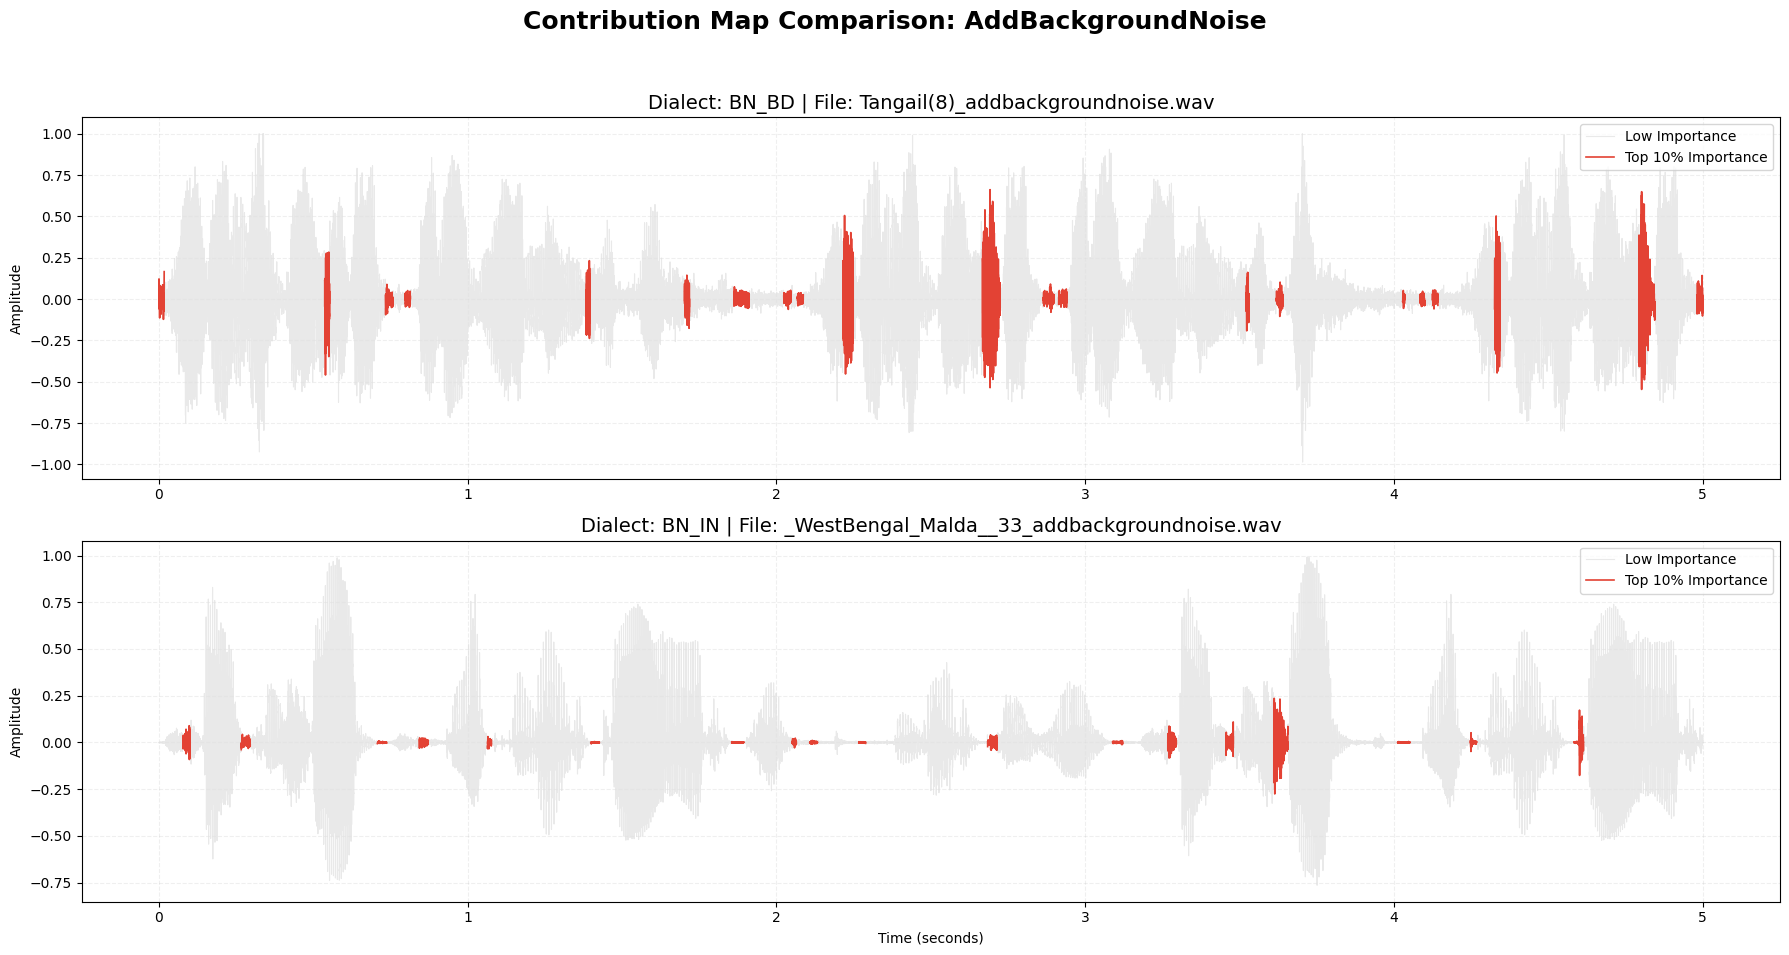

Saved comparison plot to: /kaggle/working/comparison_addbackgroundnoise.png


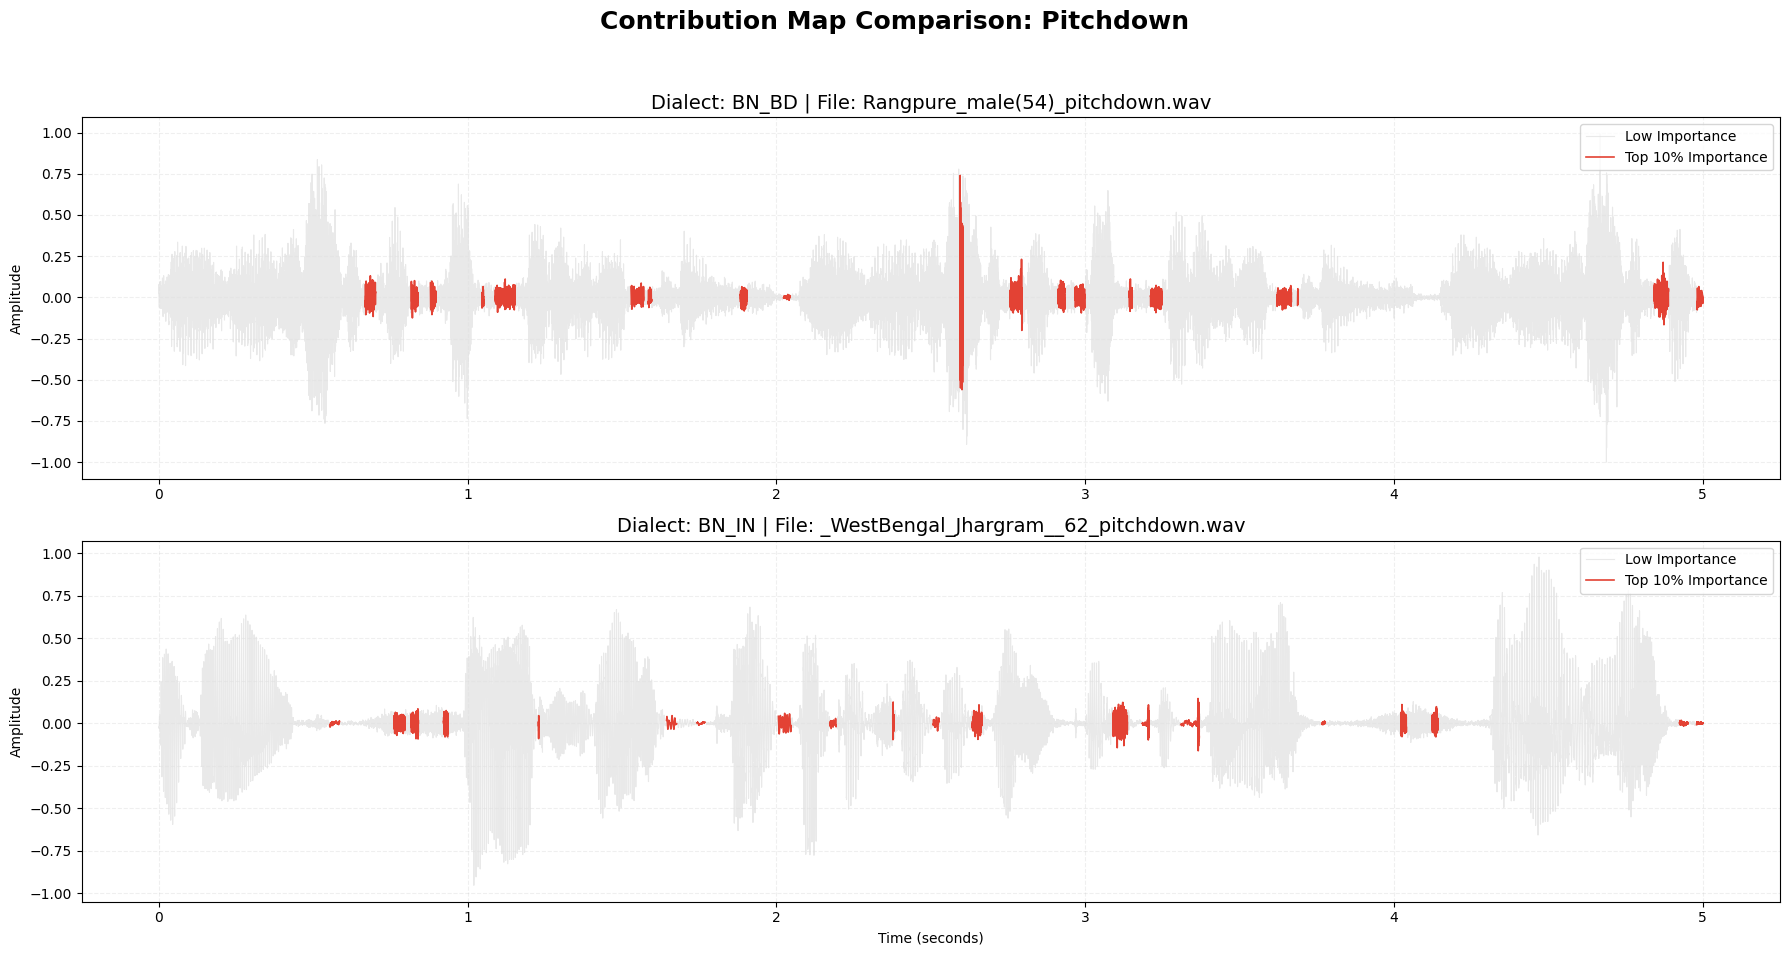

Saved comparison plot to: /kaggle/working/comparison_pitchdown.png


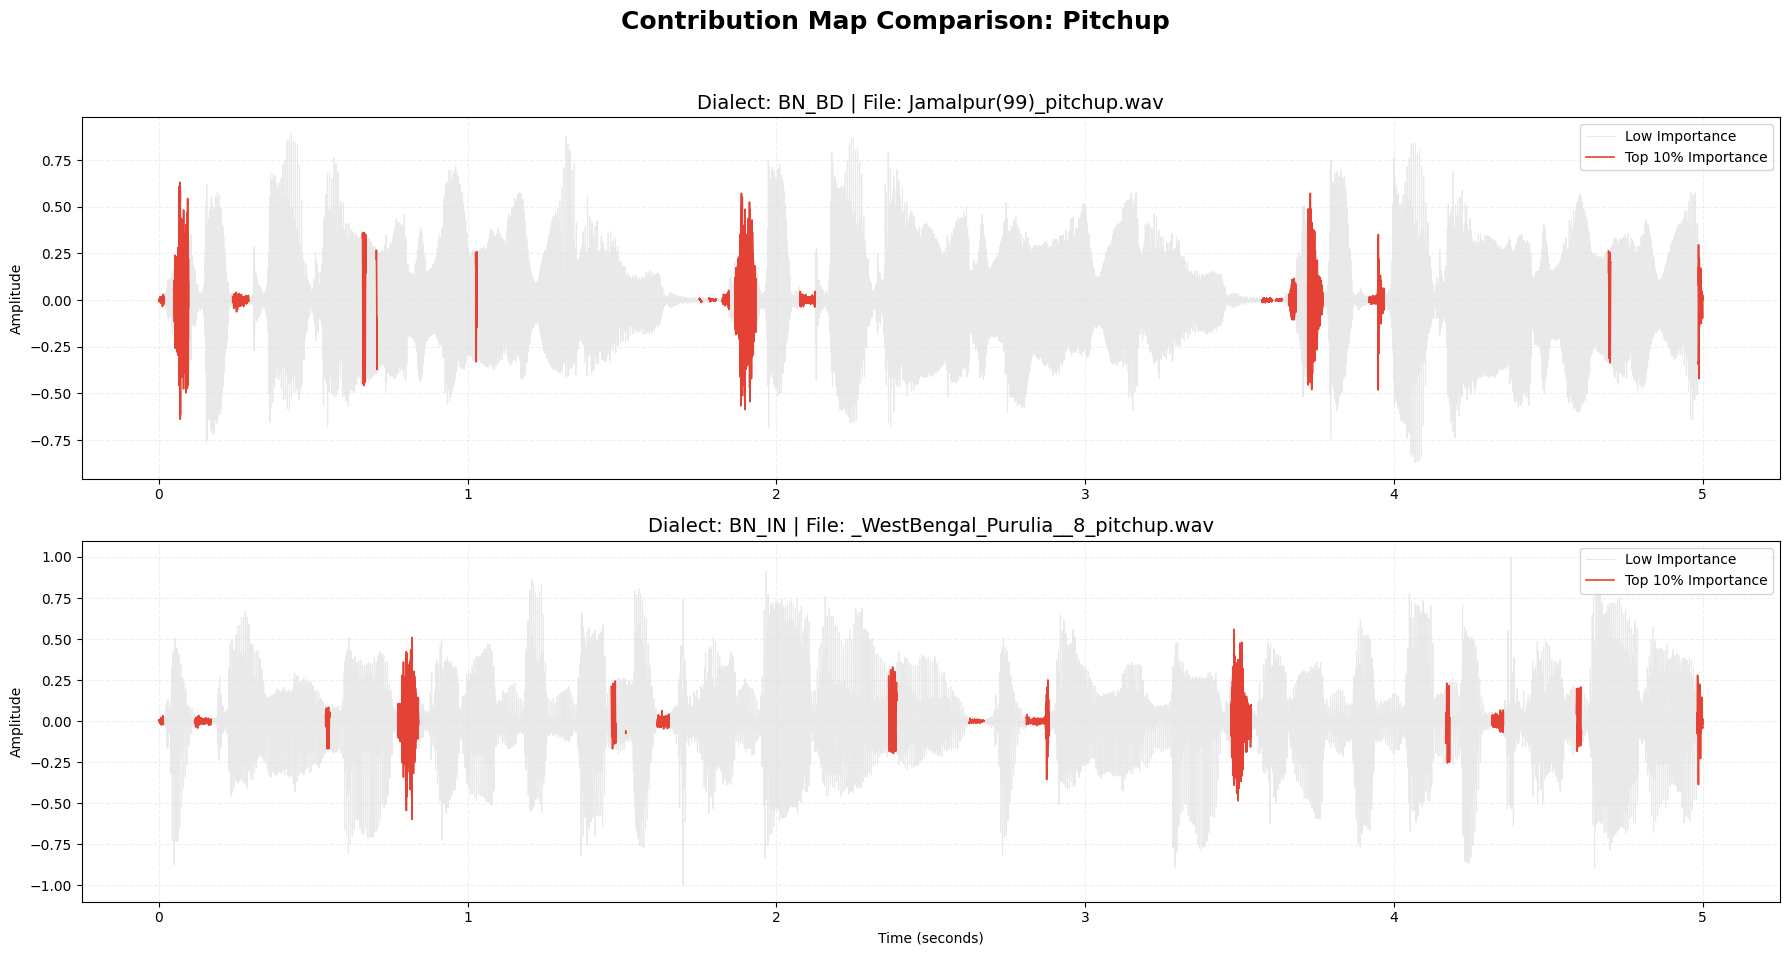

Saved comparison plot to: /kaggle/working/comparison_pitchup.png


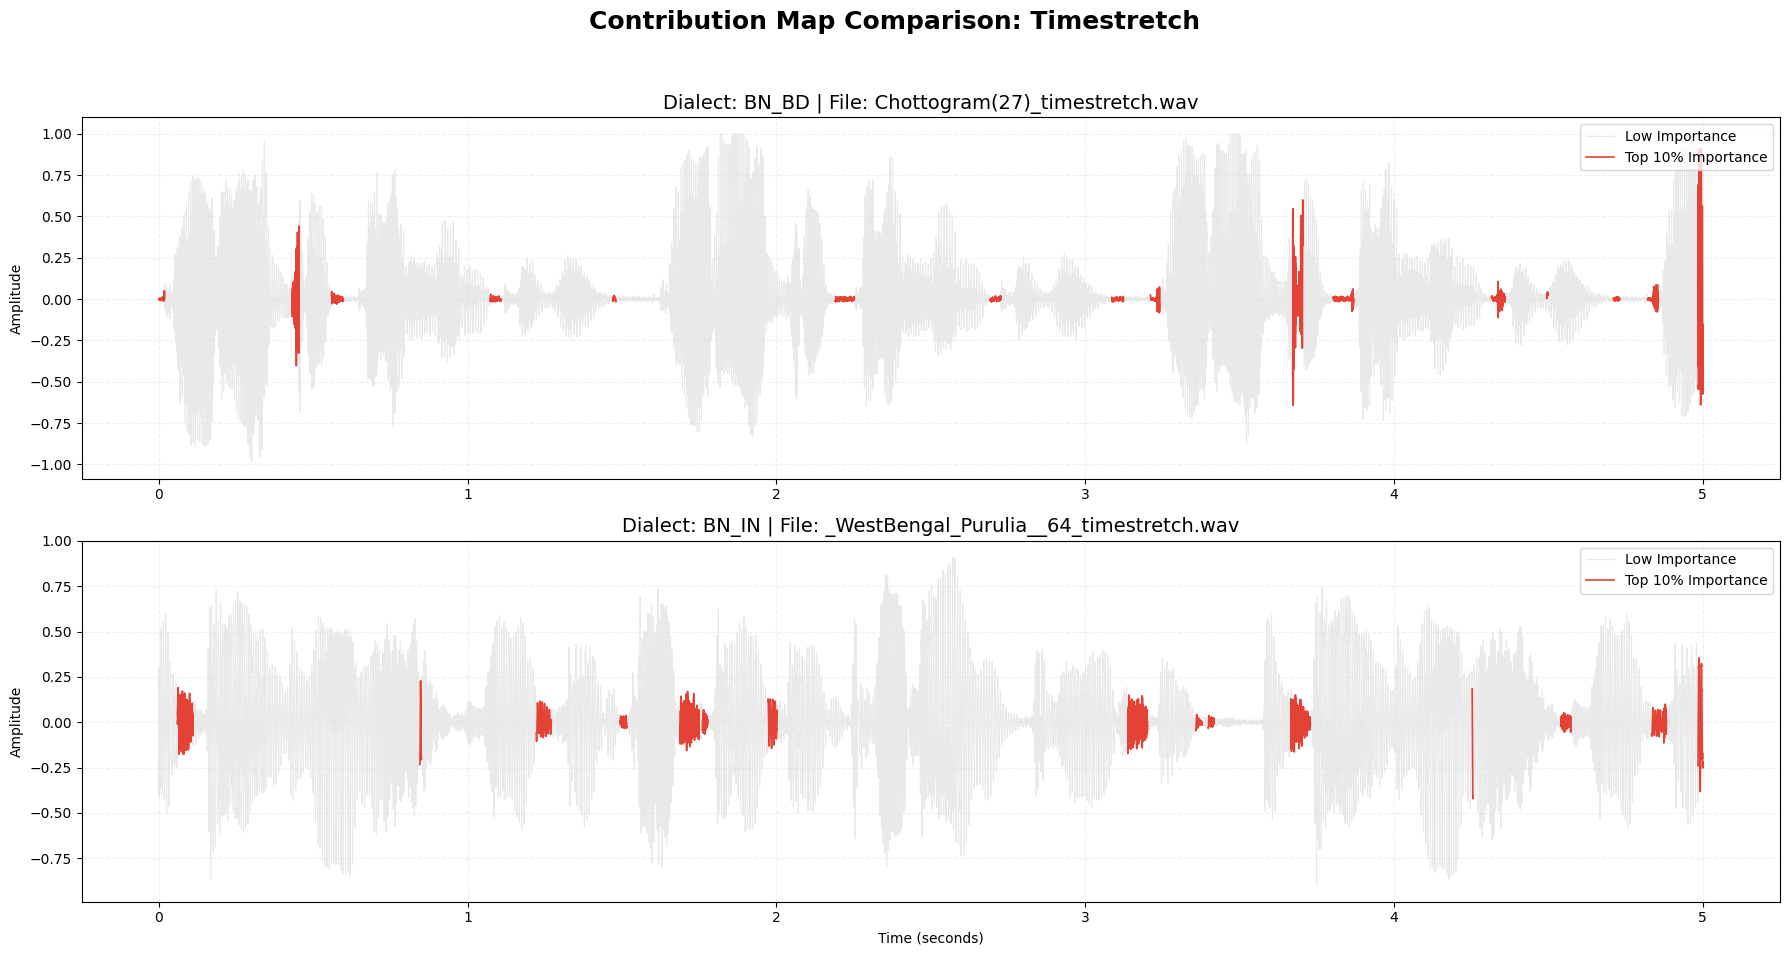

Saved comparison plot to: /kaggle/working/comparison_timestretch.png


In [30]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import librosa
import torch

# 1. Paths based on your Test Data structure
test_source_base = '/kaggle/input/datasets/pradiphazra2/dialectal-datasets/Test_Data_Fixed/Test'
augmentations = ['AddBackgroundNoise', 'Pitchdown', 'Pitchup', 'Timestretch']
dialects = ['bn_bd', 'bn_in']

def generate_comparison_plots():
    model.eval()
    
    for aug in augmentations:
        fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=False)
        fig.suptitle(f"Contribution Map Comparison: {aug}", fontsize=18, fontweight='bold', y=0.98)

        for i, dialect in enumerate(dialects):
            # Navigate to the specific augmentation folder
            folder_path = os.path.join(test_source_base, dialect, aug)
            
            if not os.path.exists(folder_path):
                print(f"Directory not found: {folder_path}")
                continue
            
            files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]
            if not files: continue
            
            # Select random file
            sample_path = os.path.join(folder_path, random.choice(files))
            
            # --- Inference & Importance Extraction ---
            audio, sr = librosa.load(sample_path, sr=feature_extractor.sampling_rate)
            inputs = feature_extractor(audio, sampling_rate=sr, return_tensors="pt").to(device)
            
            with torch.no_grad():
                outputs = model(inputs.input_values, output_attentions=True)
            
            # Get Attention (Mean of last layer)
            attentions = outputs.attentions[-1].squeeze(0).mean(dim=0).cpu().numpy()
            importance = attentions.mean(axis=0) 
            
            # Interpolate and find Top 10%
            importance_upsampled = np.interp(np.linspace(0, 1, len(audio)), 
                                             np.linspace(0, 1, len(importance)), 
                                             importance)
            threshold = np.percentile(importance_upsampled, 90)
            top_10_mask = importance_upsampled >= threshold

            # --- Plotting ---
            ax = axes[i]
            time = np.linspace(0, len(audio)/sr, num=len(audio))
            
            # Base Waveform (Light Gray)
            ax.plot(time, audio, color='#E0E0E0', label='Low Importance', linewidth=0.8, alpha=0.7)
            
            # Highlighted Segments (Red)
            highlighted_audio = np.ma.masked_where(~top_10_mask, audio)
            ax.plot(time, highlighted_audio, color='#E34234', label='Top 10% Importance', linewidth=1.2)
            
            ax.set_title(f"Dialect: {dialect.upper()} | File: {os.path.basename(sample_path)}", fontsize=14)
            ax.set_ylabel("Amplitude")
            ax.grid(True, which='both', linestyle='--', alpha=0.2)
            ax.legend(loc='upper right')
            
            if i == 1:
                ax.set_xlabel("Time (seconds)")

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        
        # Save to working directory for your report
        save_path = f"/kaggle/working/comparison_{aug.lower()}.png"
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Saved comparison plot to: {save_path}")

# --- Run the generation ---
if 'model' in globals():
    generate_comparison_plots()
else:
    print("Please ensure your 'model' is initialized and loaded before running this.")